In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    matthews_corrcoef, cohen_kappa_score, jaccard_score,
    hamming_loss, confusion_matrix, classification_report
)
from transformers import (
    DistilBertTokenizer, DistilBertModel,
    XLMRobertaTokenizer, XLMRobertaModel
)
from torch.optim import AdamW  # Updated import
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Original dataset shape: (7000, 2)

Missing values before cleaning:
preprocessed_content    173
sentiment                 0
dtype: int64

Dataset shape after removing missing values: (6827, 2)
Removed 173 rows with missing values

Sample data:
                                preprocessed_content sentiment
0  My anxiety is telling me not to be honest/vuln...   Anxiety
1  Worried I have ovarian cancer. The more I'm on...   Anxiety
2  For HA Sufferers with different anxieties than...   Anxiety
3  Eye floaters from stress? Hello, I recently we...   Anxiety
4  There is excessive anxiety today, .And, there ...   Anxiety

Missing values after cleaning:
preprocessed_content    0
sentiment               0
dtype: int64

Class distribution:
sentiment
Depression              1000
Suicidal                1000
Normal                   999
Anxiety                  992
Bipolar                  971
Stress                   970
Personality disorder     895
Name: count, dtype: int64


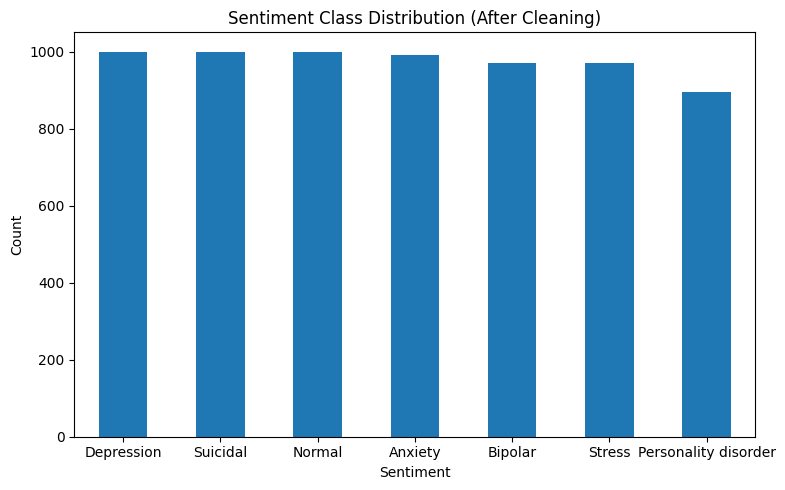

In [ ]:
# Cell 2: Load and explore dataset
df = pd.read_csv('/kaggle/input/senti-data/dataset.csv')
print("Original dataset shape:", df.shape)

# Remove missing values
print(f"\nMissing values before cleaning:")
print(df.isnull().sum())

# Drop rows with missing values
df_cleaned = df.dropna()
print(f"\nDataset shape after removing missing values: {df_cleaned.shape}")
print(f"Removed {df.shape[0] - df_cleaned.shape[0]} rows with missing values")

print("\nSample data:")
print(df_cleaned.head())

# Verify no missing values remain
print("\nMissing values after cleaning:")
print(df_cleaned.isnull().sum())

# Check class distribution
print("\nClass distribution:")
print(df_cleaned['sentiment'].value_counts())

# Plot class distribution
plt.figure(figsize=(8, 5))
df_cleaned['sentiment'].value_counts().plot(kind='bar')
plt.title('Sentiment Class Distribution (After Cleaning)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Update df to use the cleaned version for subsequent analysis
df = df_cleaned

In [ ]:
# Cell 3: Define custom dataset class
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer1, tokenizer2, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer1 = tokenizer1
        self.tokenizer2 = tokenizer2
        self.max_length = max_length
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Tokenize text with both tokenizers
        encoding1 = self.tokenizer1(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            return_token_type_ids=True,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        encoding2 = self.tokenizer2(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'text': text,
            'input_ids1': encoding1['input_ids'].flatten(),
            'attention_mask1': encoding1['attention_mask'].flatten(),
            'token_type_ids1': encoding1.get('token_type_ids', torch.zeros(self.max_length)).flatten(),
            'input_ids2': encoding2['input_ids'].flatten(),
            'attention_mask2': encoding2['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
# Cell 4: Split data into train, validation, and test sets
# Convert class labels to numeric if needed
label_mapping = {label: idx for idx, label in enumerate(df['sentiment'].unique())}
inverse_mapping = {idx: label for label, idx in label_mapping.items()}
df['label_numeric'] = df['sentiment'].map(label_mapping)

# Split the data
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['sentiment'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['sentiment'])

print(f"Train set: {train_df.shape[0]} samples")
print(f"Validation set: {val_df.shape[0]} samples")
print(f"Test set: {test_df.shape[0]} samples")


Train set: 4778 samples
Validation set: 1024 samples
Test set: 1025 samples


In [ ]:
# Cell 5: Initialize tokenizers
# For DistilBERT
distilbert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# For XLM-RoBERTa
xlmr_tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

In [ ]:
# Cell 6: Create DataLoaders
# Hyperparameters
MAX_LENGTH = 128
BATCH_SIZE = 16

# Create datasets
train_dataset = SentimentDataset(
    train_df['preprocessed_content'].values,
    train_df['label_numeric'].values,
    distilbert_tokenizer,
    xlmr_tokenizer,
    MAX_LENGTH
)

val_dataset = SentimentDataset(
    val_df['preprocessed_content'].values,
    val_df['label_numeric'].values,
    distilbert_tokenizer,
    xlmr_tokenizer,
    MAX_LENGTH
)

test_dataset = SentimentDataset(
    test_df['preprocessed_content'].values,
    test_df['label_numeric'].values,
    distilbert_tokenizer,
    xlmr_tokenizer,
    MAX_LENGTH
)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

In [ ]:
# Cell 7: Define Hybrid Transformer Model with Early Fusion
class HybridTransformerEarlyFusion(nn.Module):
    def __init__(self, num_classes):
        super(HybridTransformerEarlyFusion, self).__init__()
        # DistilBERT model
        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        # XLM-RoBERTa model
        self.xlmr = XLMRobertaModel.from_pretrained('xlm-roberta-base')
        
        # Freeze the base models (optional, can be configured)
        for param in self.distilbert.parameters():
            param.requires_grad = False
        
        for param in self.xlmr.parameters():
            param.requires_grad = False
            
        # Unfreeze the last layers (fine-tuning)
        for param in self.distilbert.transformer.layer[-2:].parameters():
            param.requires_grad = True
            
        for param in self.xlmr.encoder.layer[-2:].parameters():
            param.requires_grad = True
        
        # Feature dimensions
        self.distilbert_dim = 768
        self.xlmr_dim = 768
        
        # Fusion layers
        self.fusion_dim = self.distilbert_dim + self.xlmr_dim
        self.fusion_dropout = nn.Dropout(0.3)
        self.fusion_layer1 = nn.Linear(self.fusion_dim, 512)
        self.fusion_layer2 = nn.Linear(512, 256)
        self.classifier = nn.Linear(256, num_classes)
        
    def forward(self, input_ids1, attention_mask1, token_type_ids1, 
                input_ids2, attention_mask2):
        # Get embeddings from DistilBERT
        distilbert_output = self.distilbert(
            input_ids=input_ids1,
            attention_mask=attention_mask1
        )
        distilbert_embeddings = distilbert_output.last_hidden_state[:, 0, :]  # CLS token
        
        # Get embeddings from XLM-RoBERTa
        xlmr_output = self.xlmr(
            input_ids=input_ids2,
            attention_mask=attention_mask2
        )
        xlmr_embeddings = xlmr_output.last_hidden_state[:, 0, :]  # CLS token
        
        # Early fusion: concatenate embeddings
        fused_embeddings = torch.cat((distilbert_embeddings, xlmr_embeddings), dim=1)
        
        # Apply fusion layers
        x = self.fusion_dropout(fused_embeddings)
        x = F.relu(self.fusion_layer1(x))
        x = self.fusion_dropout(x)
        x = F.relu(self.fusion_layer2(x))
        x = self.fusion_dropout(x)
        
        # Classification
        logits = self.classifier(x)
        
        return logits

In [ ]:
# Cell 8: Define Hybrid Transformer Model with Late Fusion
class HybridTransformerLateFusion(nn.Module):
    def __init__(self, num_classes):
        super(HybridTransformerLateFusion, self).__init__()
        # DistilBERT model
        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        # XLM-RoBERTa model
        self.xlmr = XLMRobertaModel.from_pretrained('xlm-roberta-base')
        
        # Freeze the base models (optional)
        for param in self.distilbert.parameters():
            param.requires_grad = False
        
        for param in self.xlmr.parameters():
            param.requires_grad = False
            
        # Unfreeze the last layers (fine-tuning)
        for param in self.distilbert.transformer.layer[-2:].parameters():

            param.requires_grad = True
            
        for param in self.xlmr.encoder.layer[-2:].parameters():
            param.requires_grad = True
        
        # Feature dimensions
        self.distilbert_dim = 768
        self.xlmr_dim = 768
        
        # Individual classifiers
        self.dropout = nn.Dropout(0.3)
        self.distilbert_classifier = nn.Sequential(
            nn.Linear(self.distilbert_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )
        
        self.xlmr_classifier = nn.Sequential(
            nn.Linear(self.xlmr_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )
        
        # Weights for ensemble (learnable)
        self.model_weights = nn.Parameter(torch.ones(2))
        
    def forward(self, input_ids1, attention_mask1, token_type_ids1, 
                input_ids2, attention_mask2):
        # Get embeddings from DistilBERT
        distilbert_output = self.distilbert(
            input_ids=input_ids1,
            attention_mask=attention_mask1
        )
        distilbert_embeddings = distilbert_output.last_hidden_state[:, 0, :]  # CLS token
        
        # Get embeddings from XLM-RoBERTa
        xlmr_output = self.xlmr(
            input_ids=input_ids2,
            attention_mask=attention_mask2
        )
        xlmr_embeddings = xlmr_output.last_hidden_state[:, 0, :]  # CLS token
        
        # Get individual model predictions
        distilbert_logits = self.distilbert_classifier(self.dropout(distilbert_embeddings))
        xlmr_logits = self.xlmr_classifier(self.dropout(xlmr_embeddings))
        
        # Normalize weights
        weights = F.softmax(self.model_weights, dim=0)
        
        # Late fusion: weighted average of logits
        combined_logits = weights[0] * distilbert_logits + weights[1] * xlmr_logits
        
        return combined_logits, weights, distilbert_logits, xlmr_logits

In [ ]:
# Cell 9: Training function
def train_model(model, train_loader, val_loader, optimizer, scheduler, criterion, num_epochs, model_type):
    best_val_f1 = 0
    train_losses = []
    val_losses = []
    val_f1_scores = []
    
    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0
        
        train_progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for batch in train_progress:
            # Move batch to device
            input_ids1 = batch['input_ids1'].to(device)
            attention_mask1 = batch['attention_mask1'].to(device)
            token_type_ids1 = batch['token_type_ids1'].to(device)
            input_ids2 = batch['input_ids2'].to(device)
            attention_mask2 = batch['attention_mask2'].to(device)
            labels = batch['label'].to(device)
            
            # Forward pass
            optimizer.zero_grad()
            
            if model_type == 'early_fusion':
                outputs = model(
                    input_ids1, attention_mask1, token_type_ids1,
                    input_ids2, attention_mask2
                )
                loss = criterion(outputs, labels)
            else:  # late_fusion
                outputs, weights, _, _ = model(
                    input_ids1, attention_mask1, token_type_ids1,
                    input_ids2, attention_mask2
                )
                loss = criterion(outputs, labels)
            
            # Backward pass and optimize
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            total_train_loss += loss.item()
            train_progress.set_postfix({'loss': loss.item()})
        
        # Calculate average training loss
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validation
        model.eval()
        total_val_loss = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            val_progress = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
            for batch in val_progress:
                # Move batch to device
                input_ids1 = batch['input_ids1'].to(device)
                attention_mask1 = batch['attention_mask1'].to(device)
                token_type_ids1 = batch['token_type_ids1'].to(device)
                input_ids2 = batch['input_ids2'].to(device)
                attention_mask2 = batch['attention_mask2'].to(device)
                labels = batch['label'].to(device)
                
                # Forward pass
                if model_type == 'early_fusion':
                    outputs = model(
                        input_ids1, attention_mask1, token_type_ids1,
                        input_ids2, attention_mask2
                    )
                    loss = criterion(outputs, labels)
                    preds = torch.argmax(outputs, dim=1)
                else:  # late_fusion
                    outputs, weights, _, _ = model(
                        input_ids1, attention_mask1, token_type_ids1,
                        input_ids2, attention_mask2
                    )
                    loss = criterion(outputs, labels)
                    preds = torch.argmax(outputs, dim=1)
                
                total_val_loss += loss.item()
                
                # Collect predictions and labels
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
                val_progress.set_postfix({'loss': loss.item()})
        
        # Calculate average validation loss
        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        # Calculate validation metrics
        val_f1 = f1_score(all_labels, all_preds, average='weighted')
        val_f1_scores.append(val_f1)
        
        # Update learning rate
        if scheduler:
            scheduler.step(avg_val_loss)
        
        # Print epoch results
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print(f"Train Loss: {avg_train_loss:.4f}")
        print(f"Val Loss: {avg_val_loss:.4f}")
        print(f"Val F1 Score: {val_f1:.4f}")
        
        if model_type == 'late_fusion':
            print(f"Model Weights: {weights.cpu().detach().numpy()}")
        
        # Save best model
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), f'best_{model_type}_model.pt')
            print(f"New best model saved with F1 Score: {best_val_f1:.4f}")
    
    # Return training history
    return train_losses, val_losses, val_f1_scores

In [ ]:
# Cell 10: Initialize Early Fusion model and train
num_classes = len(label_mapping)
early_fusion_model = HybridTransformerEarlyFusion(num_classes).to(device)

# Set up optimizer and scheduler
optimizer = AdamW(
    [p for p in early_fusion_model.parameters() if p.requires_grad],
    lr=2e-5,
    eps=1e-8
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    verbose=True
)

# Loss function
criterion = nn.CrossEntropyLoss()

# Train the model
print("Training Early Fusion Model...")
early_train_losses, early_val_losses, early_val_f1 = train_model(
    early_fusion_model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    criterion,
    num_epochs=10,
    model_type='early_fusion'
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Training Early Fusion Model...


Epoch 1/10 [Train]:   0%|          | 0/299 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/64 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/64 [00:00<?, ?it/s]


Epoch 9/10
Train Loss: 0.2771
Val Loss: 0.6895
Val F1 Score: 0.7871


Epoch 10/10 [Train]:   0%|          | 0/299 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/64 [00:00<?, ?it/s]


Epoch 10/10
Train Loss: 0.2504
Val Loss: 0.6794
Val F1 Score: 0.7928


In [ ]:
# Cell 11: Initialize Late Fusion model and train
late_fusion_model = HybridTransformerLateFusion(num_classes).to(device)

# Set up optimizer and scheduler
optimizer = AdamW(
    [p for p in late_fusion_model.parameters() if p.requires_grad],
    lr=2e-5,
    eps=1e-8
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    verbose=True
)

# Train the model
print("Training Late Fusion Model...")
late_train_losses, late_val_losses, late_val_f1 = train_model(
    late_fusion_model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    criterion,
    num_epochs=10,
    model_type='late_fusion'
)

Training Late Fusion Model...


Epoch 1/10 [Train]:   0%|          | 0/299 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/64 [00:00<?, ?it/s]


Epoch 1/10
Train Loss: 1.6080
Val Loss: 1.0972
Val F1 Score: 0.6256
Model Weights: [0.50267214 0.49732786]
New best model saved with F1 Score: 0.6256


Epoch 2/10 [Train]:   0%|          | 0/299 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/64 [00:00<?, ?it/s]


Epoch 9/10
Train Loss: 0.2617
Val Loss: 0.5985
Val F1 Score: 0.7953
Model Weights: [0.516393   0.48360696]
New best model saved with F1 Score: 0.7953


Epoch 10/10 [Train]:   0%|          | 0/299 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/64 [00:00<?, ?it/s]


Epoch 10/10
Train Loss: 0.2185
Val Loss: 0.6136
Val F1 Score: 0.7948
Model Weights: [0.5172983 0.4827017]


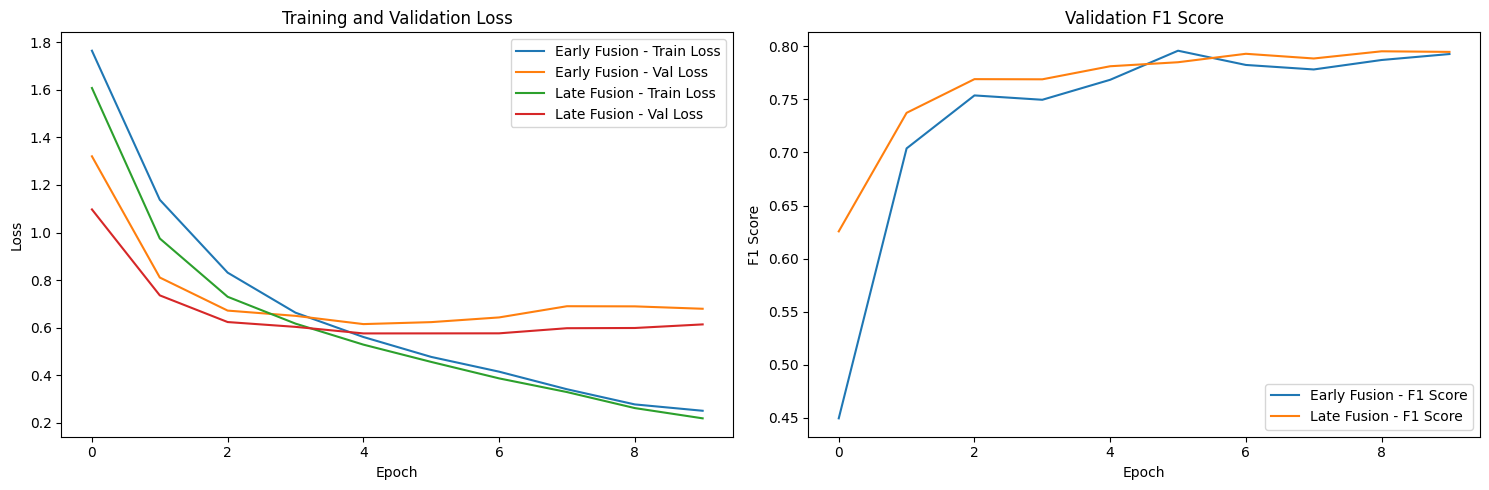

In [ ]:
# Cell 12: Plot training and validation metrics
plt.figure(figsize=(15, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(early_train_losses, label='Early Fusion - Train Loss')
plt.plot(early_val_losses, label='Early Fusion - Val Loss')
plt.plot(late_train_losses, label='Late Fusion - Train Loss')
plt.plot(late_val_losses, label='Late Fusion - Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# F1 score plot
plt.subplot(1, 2, 2)
plt.plot(early_val_f1, label='Early Fusion - F1 Score')
plt.plot(late_val_f1, label='Late Fusion - F1 Score')
plt.title('Validation F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Cell 13: Evaluate models on test set
def evaluate_model(model, test_loader, model_type):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            # Move batch to device
            input_ids1 = batch['input_ids1'].to(device)
            attention_mask1 = batch['attention_mask1'].to(device)
            token_type_ids1 = batch['token_type_ids1'].to(device)
            input_ids2 = batch['input_ids2'].to(device)
            attention_mask2 = batch['attention_mask2'].to(device)
            labels = batch['label'].to(device)
            
            # Forward pass
            if model_type == 'early_fusion':
                outputs = model(
                    input_ids1, attention_mask1, token_type_ids1,
                    input_ids2, attention_mask2
                )
                preds = torch.argmax(outputs, dim=1)
            else:  # late_fusion
                outputs, weights, distilbert_logits, xlmr_logits = model(
                    input_ids1, attention_mask1, token_type_ids1,
                    input_ids2, attention_mask2
                )
                preds = torch.argmax(outputs, dim=1)
                
                # Also get individual model predictions for analysis
                distilbert_preds = torch.argmax(distilbert_logits, dim=1)
                xlmr_preds = torch.argmax(xlmr_logits, dim=1)
            
            # Collect predictions and labels
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Convert to numpy arrays for metrics calculation
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, average='weighted'),
        'recall': recall_score(all_labels, all_preds, average='weighted'),
        'f1': f1_score(all_labels, all_preds, average='weighted'),
        'mcc': matthews_corrcoef(all_labels, all_preds),
        'cohen_kappa': cohen_kappa_score(all_labels, all_preds),
        'jaccard': jaccard_score(all_labels, all_preds, average='weighted'),
        'hamming_loss': hamming_loss(all_labels, all_preds)
    }
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # Classification report
    cr = classification_report(all_labels, all_preds, target_names=list(inverse_mapping.values()), output_dict=True)
    
    return metrics, cm, cr, all_preds, all_labels

# Load the best early fusion model
early_fusion_model.load_state_dict(torch.load('best_early_fusion_model.pt'))
early_metrics, early_cm, early_cr, early_preds, early_labels = evaluate_model(
    early_fusion_model, 
    test_loader, 
    'early_fusion'
)

# Load the best late fusion model
late_fusion_model.load_state_dict(torch.load('best_late_fusion_model.pt'))
late_metrics, late_cm, late_cr, late_preds, late_labels = evaluate_model(
    late_fusion_model, 
    test_loader, 
    'late_fusion'
)

Evaluating:   0%|          | 0/65 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/65 [00:00<?, ?it/s]

In [ ]:
# Cell 14: Display evaluation metrics
print("Early Fusion Model Metrics:")
for metric, value in early_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nLate Fusion Model Metrics:")
for metric, value in late_metrics.items():
    print(f"{metric}: {value:.4f}")

Early Fusion Model Metrics:
accuracy: 0.7444
precision: 0.7569
recall: 0.7444
f1: 0.7452
mcc: 0.7037
cohen_kappa: 0.7018
jaccard: 0.6014
hamming_loss: 0.2556

Late Fusion Model Metrics:
accuracy: 0.7668
precision: 0.7690
recall: 0.7668
f1: 0.7654
mcc: 0.7288
cohen_kappa: 0.7279
jaccard: 0.6268
hamming_loss: 0.2332


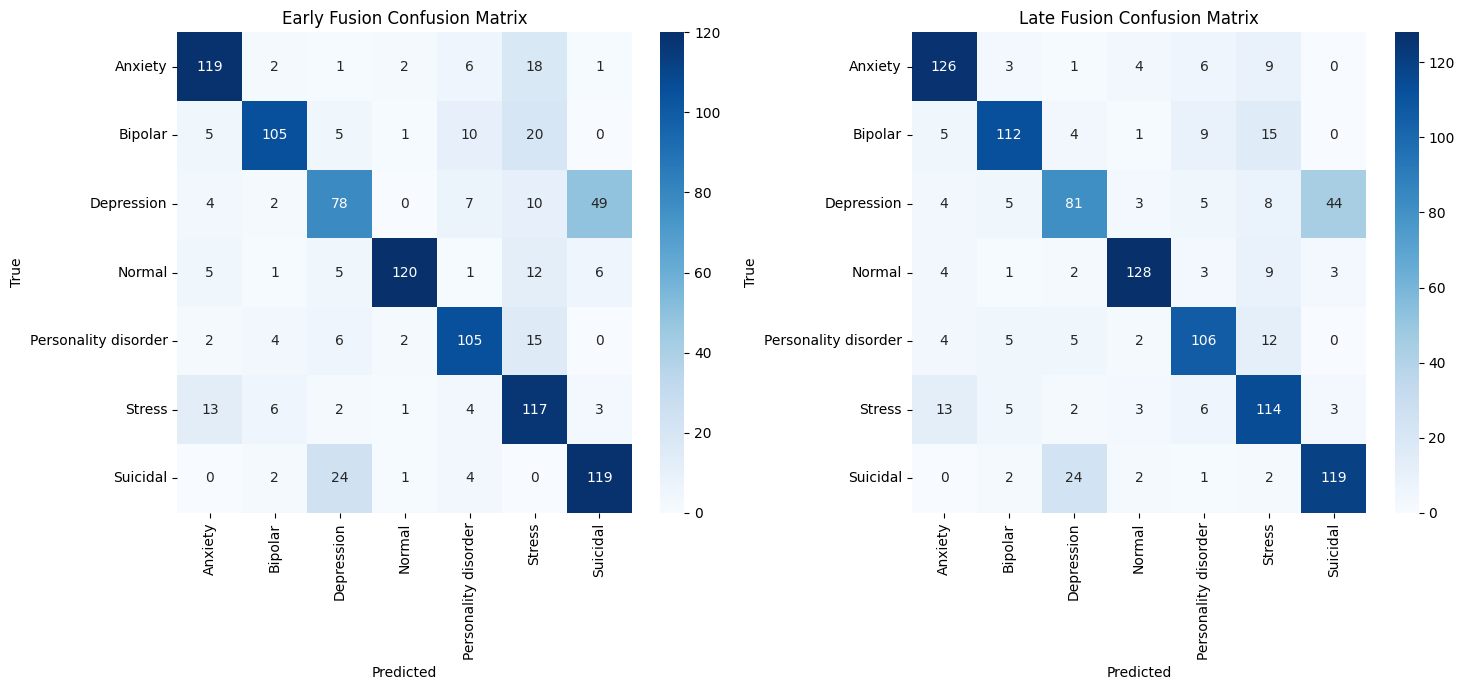

In [ ]:
# Cell 15: Plot confusion matrices
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
sns.heatmap(early_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=list(inverse_mapping.values()),
            yticklabels=list(inverse_mapping.values()))
plt.title('Early Fusion Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.subplot(1, 2, 2)
sns.heatmap(late_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=list(inverse_mapping.values()),
            yticklabels=list(inverse_mapping.values()))
plt.title('Late Fusion Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.tight_layout()
plt.show()

Early Fusion Classification Report:


,Class,Precision,Recall,F1-Score,Support
0,Anxiety,0.804054,0.798658,0.801347,149
1,Bipolar,0.860656,0.719178,0.783582,146
2,Depression,0.644628,0.520000,0.575646,150
3,Normal,0.944882,0.800000,0.866426,150
4,Personality disorder,0.766423,0.783582,0.774908,134
5,Stress,0.609375,0.801370,0.692308,146
6,Suicidal,0.668539,0.793333,0.725610,150


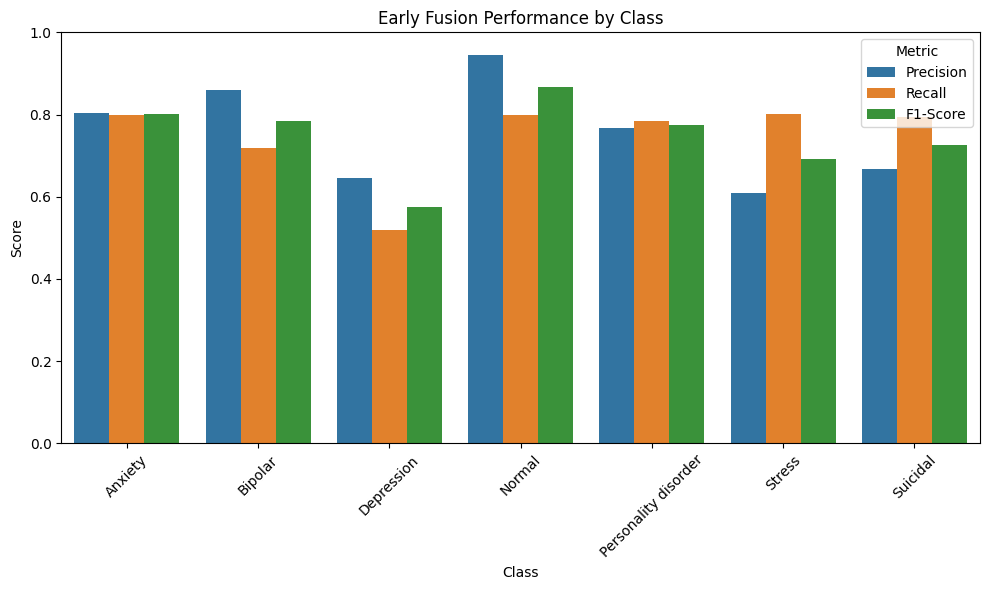


Late Fusion Classification Report:


,Class,Precision,Recall,F1-Score,Support
0,Anxiety,0.807692,0.845638,0.826230,149
1,Bipolar,0.842105,0.767123,0.802867,146
2,Depression,0.680672,0.540000,0.602230,150
3,Normal,0.895105,0.853333,0.873720,150
4,Personality disorder,0.779412,0.791045,0.785185,134
5,Stress,0.674556,0.780822,0.723810,146
6,Suicidal,0.704142,0.793333,0.746082,150


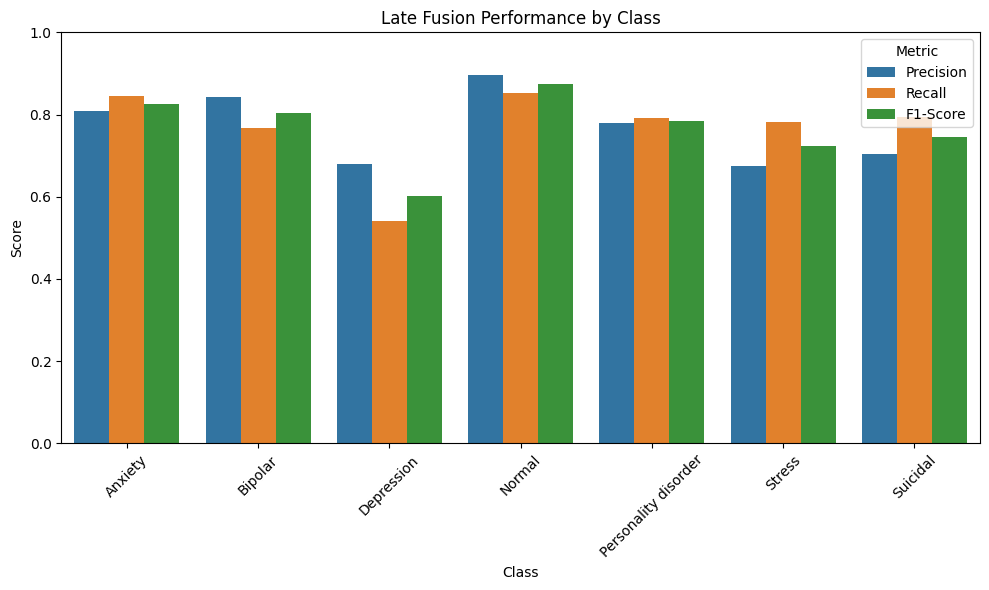

In [ ]:
# Cell 16: Create and display classification reports
def plot_classification_report(cr, title):
    # Extract metrics from classification report
    classes = list(cr.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
    
    # Create a DataFrame for better visualization
    report_df = pd.DataFrame({
        'Class': classes,
        'Precision': [cr[cls]['precision'] for cls in classes],
        'Recall': [cr[cls]['recall'] for cls in classes],
        'F1-Score': [cr[cls]['f1-score'] for cls in classes],
        'Support': [cr[cls]['support'] for cls in classes]
    })
    
    # Display the report as a styled table
    styled_report = report_df.style.background_gradient(cmap='Blues', subset=['Precision', 'Recall', 'F1-Score'])
    display(styled_report)
    
    # Plot the metrics
    plt.figure(figsize=(10, 6))
    metrics_df = report_df.melt(id_vars='Class', value_vars=['Precision', 'Recall', 'F1-Score'], 
                               var_name='Metric', value_name='Score')
    sns.barplot(x='Class', y='Score', hue='Metric', data=metrics_df)
    plt.title(title)
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

print("Early Fusion Classification Report:")
plot_classification_report(early_cr, 'Early Fusion Performance by Class')

print("\nLate Fusion Classification Report:")
plot_classification_report(late_cr, 'Late Fusion Performance by Class')

Model Comparison:


,Metric,Early Fusion,Late Fusion
0,accuracy,0.744390,0.766829
1,precision,0.756914,0.768983
2,recall,0.744390,0.766829
3,f1,0.745239,0.765388
4,mcc,0.703667,0.728790
5,cohen_kappa,0.701767,0.727931
6,jaccard,0.601359,0.626786
7,hamming_loss,0.255610,0.233171


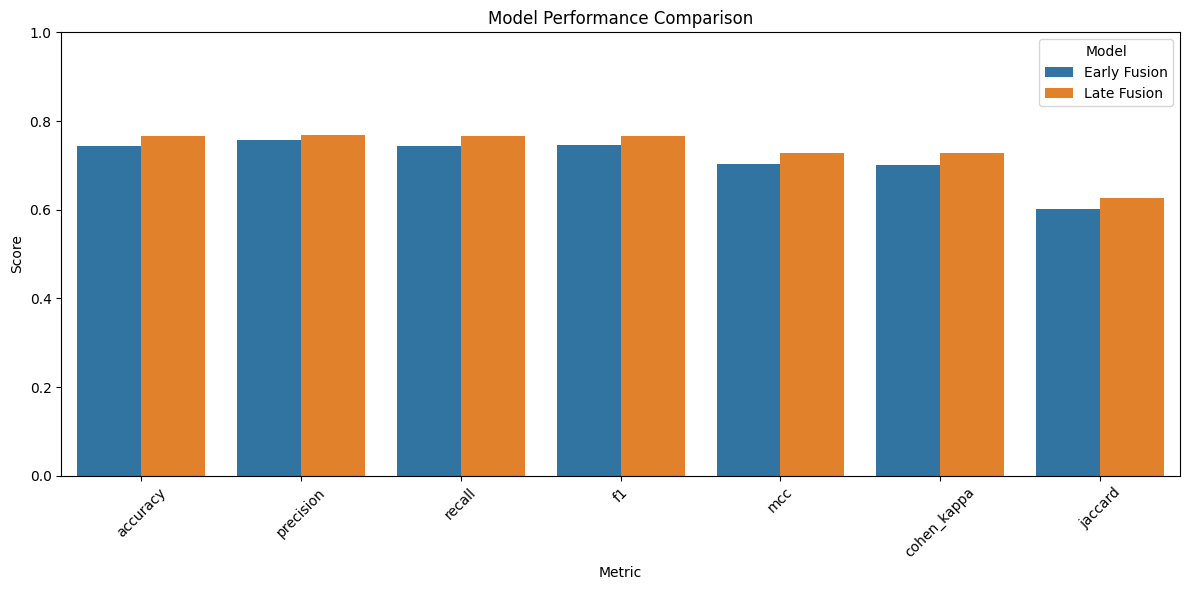


Based on F1 score, the better performing model is: Late Fusion
Performance improvement: 2.70%


In [ ]:
# Cell 17: Compare models and determine the best approach
# Create a comparison table
comparison_df = pd.DataFrame({
    'Metric': list(early_metrics.keys()),
    'Early Fusion': list(early_metrics.values()),
    'Late Fusion': list(late_metrics.values())
})

print("Model Comparison:")
display(comparison_df)

# Plot comparison
plt.figure(figsize=(12, 6))
comparison_df_plot = comparison_df[comparison_df['Metric'] != 'hamming_loss']  # Exclude hamming_loss as it's lower is better
comparison_df_plot = comparison_df_plot.melt(id_vars='Metric', var_name='Model', value_name='Score')
sns.barplot(x='Metric', y='Score', hue='Model', data=comparison_df_plot)
plt.title('Model Performance Comparison')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Determine which model performs better
better_model = "Early Fusion" if early_metrics['f1'] > late_metrics['f1'] else "Late Fusion"
print(f"\nBased on F1 score, the better performing model is: {better_model}")

# Calculate performance improvement
improvement = abs(early_metrics['f1'] - late_metrics['f1']) / min(early_metrics['f1'], late_metrics['f1']) * 100
print(f"Performance improvement: {improvement:.2f}%")

In [ ]:
# Cell 18: Error analysis
def analyze_errors(true_labels, pred_labels, texts, model_name):
    # Identify misclassified samples
    error_indices = np.where(true_labels != pred_labels)[0]
    
    if len(error_indices) == 0:
        print(f"No errors found for {model_name}!")
        return
    
    # Create a DataFrame for error analysis
    error_df = pd.DataFrame({
        'Text': [texts[i] for i in error_indices],
        'True Label': [inverse_mapping[true_labels[i]] for i in error_indices],
        'Predicted Label': [inverse_mapping[pred_labels[i]] for i in error_indices]
    })
    
    print(f"Total errors for {model_name}: {len(error_indices)}")
    print(f"Error rate: {len(error_indices) / len(true_labels) * 100:.2f}%")
    
    # Display most common error patterns
    error_patterns = error_df.groupby(['True Label', 'Predicted Label']).size().reset_index(name='Count')
    error_patterns = error_patterns.sort_values('Count', ascending=False)
    print("\nMost common error patterns:")
    display(error_patterns.head(10))
    
    # Return a sample of errors for manual inspection
    return error_df.sample(min(10, len(error_df)))

# Get the texts from test set
test_texts = [test_dataset[i]['text'] for i in range(len(test_dataset))]

# Analyze errors for early fusion model
print("Early Fusion Model Error Analysis:")
early_error_samples = analyze_errors(early_labels, early_preds, test_texts, "Early Fusion")
if early_error_samples is not None:
    print("\nSample of misclassified texts (Early Fusion):")
    display(early_error_samples)

# Analyze errors for late fusion model
print("\nLate Fusion Model Error Analysis:")
late_error_samples = analyze_errors(late_labels, late_preds, test_texts, "Late Fusion")
if late_error_samples is not None:
    print("\nSample of misclassified texts (Late Fusion):")
    display(late_error_samples)

Early Fusion Model Error Analysis:
Total errors for Early Fusion: 262
Error rate: 25.56%

Most common error patterns:


,True Label,Predicted Label,Count
15,Depression,Suicidal,49
34,Suicidal,Depression,24
10,Bipolar,Stress,20
4,Anxiety,Stress,18
26,Personality disorder,Stress,15
27,Stress,Anxiety,13
20,Normal,Stress,12
14,Depression,Stress,10
9,Bipolar,Personality disorder,10
13,Depression,Personality disorder,7



Sample of misclassified texts (Early Fusion):


,Text,True Label,Predicted Label
207,One thing someone said to me after telling the...,Depression,Suicidal
172,Sent desperate message to a family member and ...,Personality disorder,Stress
190,"I am angry, and sad, I want to scream, and cry...",Depression,Suicidal
62,"lost best friend of 12 years also i ""think"" i...",Stress,Anxiety
164,I finally managed to give myself diabetes afte...,Depression,Suicidal
215,Death of Seasons [self-hatred] (/spoiler) I wa...,Bipolar,Depression
70,Everything feels like a blur. it is all meanin...,Depression,Suicidal
160,Bringing reusable bags to the grocery store fe...,Anxiety,Personality disorder
69,The Son (a movie) This movie is underrated.\n\...,Personality disorder,Stress
59,Could this inflammation of the throat even tho...,Normal,Anxiety



Late Fusion Model Error Analysis:
Total errors for Late Fusion: 239
Error rate: 23.32%

Most common error patterns:


,True Label,Predicted Label,Count
15,Depression,Suicidal,44
34,Suicidal,Depression,24
9,Bipolar,Stress,15
27,Stress,Anxiety,13
26,Personality disorder,Stress,12
4,Anxiety,Stress,9
8,Bipolar,Personality disorder,9
20,Normal,Stress,9
14,Depression,Stress,8
31,Stress,Personality disorder,6



Sample of misclassified texts (Late Fusion):


,Text,True Label,Predicted Label
77,I’m hungry. 😢 I’m sick to my stomach from it b...,Depression,Anxiety
203,"I just, just so... idk scary and uncertain and...",Depression,Suicidal
38,"I never thought it is possible, but I have a c...",Suicidal,Depression
238,Crying when seeing sth cute/innocent? Whenever...,Personality disorder,Depression
189,One thing someone said to me after telling the...,Depression,Suicidal
85,do not you think its time to begin again? I am...,Depression,Suicidal
172,Why do I even have to be here anymore. My pare...,Depression,Suicidal
152,Advice on how to cope traveling soon I was doi...,Anxiety,Bipolar
162,I had an anxiety attack during an action scene...,Anxiety,Stress
146,Bringing reusable bags to the grocery store fe...,Anxiety,Personality disorder


In [ ]:
# Cell 19: Save the best model
# Based on the comparison results, save the best model
if early_metrics['f1'] > late_metrics['f1']:
    best_model = early_fusion_model
    best_model_type = 'early_fusion'
else:
    best_model = late_fusion_model
    best_model_type = 'late_fusion'

# Save the model and tokenizers
torch.save({
    'model_state_dict': best_model.state_dict(),
    'model_type': best_model_type,
    'num_classes': num_classes,
    'label_mapping': label_mapping,
    'inverse_mapping': inverse_mapping,
}, 'best_hybrid_transformer_model.pt')

print(f"Best model ({best_model_type}) saved to 'best_hybrid_transformer_model.pt'")

Best model (late_fusion) saved to 'best_hybrid_transformer_model.pt'


In [ ]:
# Cell 20: Create a function for model inference
def predict_sentiment(text, model, tokenizer1, tokenizer2, label_mapping, model_type, max_length=128):
    """
    Predict sentiment for a given text using the trained hybrid model
    """
    model.eval()
    
    # Tokenize input text
    encoding1 = tokenizer1(
        text,
        add_special_tokens=True,
        max_length=max_length,
        return_token_type_ids=True,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    
    encoding2 = tokenizer2(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    
    # Move tensors to device
    input_ids1 = encoding1['input_ids'].to(device)
    attention_mask1 = encoding1['attention_mask'].to(device)
    token_type_ids1 = encoding1.get('token_type_ids', torch.zeros((1, max_length), device=device)).to(device)
    input_ids2 = encoding2['input_ids'].to(device)
    attention_mask2 = encoding2['attention_mask'].to(device)
    
    # Get prediction
    with torch.no_grad():
        if model_type == 'early_fusion':
            outputs = model(
                input_ids1, attention_mask1, token_type_ids1,
                input_ids2, attention_mask2
            )
            probabilities = F.softmax(outputs, dim=1)
            pred_class = torch.argmax(probabilities, dim=1).item()
        else:  # late_fusion
            outputs, weights, distilbert_logits, xlmr_logits = model(
                input_ids1, attention_mask1, token_type_ids1,
                input_ids2, attention_mask2
            )
            probabilities = F.softmax(outputs, dim=1)
            pred_class = torch.argmax(probabilities, dim=1).item()
            
            # Get individual model predictions
            distilbert_probs = F.softmax(distilbert_logits, dim=1)
            xlmr_probs = F.softmax(xlmr_logits, dim=1)
            
            # Return individual model predictions for analysis
            return {
                'sentiment': inverse_mapping[pred_class],
                'confidence': probabilities[0][pred_class].item(),
                'all_probabilities': probabilities[0].cpu().numpy(),
                'distilbert_sentiment': inverse_mapping[torch.argmax(distilbert_probs, dim=1).item()],
                'xlmr_sentiment': inverse_mapping[torch.argmax(xlmr_probs, dim=1).item()],
                'model_weights': weights.cpu().numpy()
            }
    
    # For early fusion, return a simpler output
    return {
        'sentiment': inverse_mapping[pred_class],
        'confidence': probabilities[0][pred_class].item(),
        'all_probabilities': probabilities[0].cpu().numpy()
    }

# Test the prediction function with a sample text
sample_text = "I really enjoyed this product. It exceeded my expectations."
prediction = predict_sentiment(
    sample_text, 
    best_model, 
    distilbert_tokenizer, 
    xlmr_tokenizer, 
    label_mapping, 
    best_model_type
)
print("\nSample prediction:")
print(f"Text: '{sample_text}'")
print(f"Predicted sentiment: {prediction['sentiment']}")
print(f"Confidence: {prediction['confidence']:.4f}")


Sample prediction:
Text: 'I really enjoyed this product. It exceeded my expectations.'
Predicted sentiment: Normal
Confidence: 0.9968


In [ ]:
# Ensemble Model Combining Early and Late Fusion
class EnsembleHybridTransformer(nn.Module):
    def __init__(self, early_fusion_model, late_fusion_model):
        super(EnsembleHybridTransformer, self).__init__()
        self.early_fusion_model = early_fusion_model
        self.late_fusion_model = late_fusion_model
        
        # Initialize learnable weights for the ensemble
        self.ensemble_weights = nn.Parameter(torch.ones(2))
        
    def forward(self, input_ids1, attention_mask1, token_type_ids1, 
                input_ids2, attention_mask2):
        # Get outputs from early fusion model
        early_outputs = self.early_fusion_model(
            input_ids1, attention_mask1, token_type_ids1,
            input_ids2, attention_mask2
        )
        
        # Get outputs from late fusion model
        late_outputs, late_weights, _, _ = self.late_fusion_model(
            input_ids1, attention_mask1, token_type_ids1,
            input_ids2, attention_mask2
        )
        
        # Normalize ensemble weights
        weights = F.softmax(self.ensemble_weights, dim=0)
        
        # Combine logits from both models
        ensemble_logits = weights[0] * early_outputs + weights[1] * late_outputs
        
        return ensemble_logits, weights, early_outputs, late_outputs

In [ ]:
# Initialize and configure the ensemble model
def load_and_evaluate_ensemble():
    # Load the best early fusion model
    early_fusion_model.load_state_dict(torch.load('best_early_fusion_model.pt'))
    early_fusion_model.eval()
    
    # Load the best late fusion model
    late_fusion_model.load_state_dict(torch.load('best_late_fusion_model.pt'))
    late_fusion_model.eval()
    
    # Create the ensemble model
    ensemble_model = EnsembleHybridTransformer(early_fusion_model, late_fusion_model).to(device)
    
    # Freeze the base models
    for param in early_fusion_model.parameters():
        param.requires_grad = False
    
    for param in late_fusion_model.parameters():
        param.requires_grad = False
    
    # Only train the ensemble weights
    optimizer = AdamW([ensemble_model.ensemble_weights], lr=0.01)
    criterion = nn.CrossEntropyLoss()
    
    # Training loop for ensemble weights
    print("Training Ensemble Model...")
    ensemble_model.train()
    best_val_f1 = 0
    
    for epoch in range(10):  # Fewer epochs since we're just training weights
        # Train on validation set to learn ensemble weights
        total_loss = 0
        train_progress = tqdm(val_loader, desc=f"Epoch {epoch+1}/10 [Ensemble Training]")
        
        for batch in train_progress:
            # Move batch to device
            input_ids1 = batch['input_ids1'].to(device)
            attention_mask1 = batch['attention_mask1'].to(device)
            token_type_ids1 = batch['token_type_ids1'].to(device)
            input_ids2 = batch['input_ids2'].to(device)
            attention_mask2 = batch['attention_mask2'].to(device)
            labels = batch['label'].to(device)
            
            # Forward pass
            optimizer.zero_grad()
            outputs, weights, _, _ = ensemble_model(
                input_ids1, attention_mask1, token_type_ids1,
                input_ids2, attention_mask2
            )
            
            loss = criterion(outputs, labels)
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            train_progress.set_postfix({'loss': loss.item(), 'weights': weights.detach().cpu().numpy()})
        
        avg_loss = total_loss / len(val_loader)
        print(f"Epoch {epoch+1}/10, Loss: {avg_loss:.4f}, Weights: {ensemble_model.ensemble_weights.detach().cpu().numpy()}")
        
        # Evaluate on test set
        ensemble_model.eval()
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for batch in tqdm(test_loader, desc="Evaluating Ensemble"):
                # Move batch to device
                input_ids1 = batch['input_ids1'].to(device)
                attention_mask1 = batch['attention_mask1'].to(device)
                token_type_ids1 = batch['token_type_ids1'].to(device)
                input_ids2 = batch['input_ids2'].to(device)
                attention_mask2 = batch['attention_mask2'].to(device)
                labels = batch['label'].to(device)
                
                # Forward pass
                outputs, _, _, _ = ensemble_model(
                    input_ids1, attention_mask1, token_type_ids1,
                    input_ids2, attention_mask2
                )
                
                preds = torch.argmax(outputs, dim=1)
                
                # Collect predictions and labels
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        # Calculate validation F1 score
        val_f1 = f1_score(all_labels, all_preds, average='weighted')
        print(f"Validation F1 Score: {val_f1:.4f}")
        
        # Save the best model
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(ensemble_model.state_dict(), 'best_ensemble_model.pt')
            print(f"New best ensemble model saved with F1 Score: {best_val_f1:.4f}")
    
    # Load the best ensemble model
    ensemble_model.load_state_dict(torch.load('best_ensemble_model.pt'))
    
    # Final evaluation on test set
    ensemble_metrics, ensemble_cm, ensemble_cr, ensemble_preds, ensemble_labels = evaluate_ensemble_model(
        ensemble_model, 
        test_loader
    )
    
    return ensemble_model, ensemble_metrics, ensemble_cm, ensemble_cr, ensemble_preds, ensemble_labels

In [ ]:
# Function to evaluate the ensemble model
def evaluate_ensemble_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            # Move batch to device
            input_ids1 = batch['input_ids1'].to(device)
            attention_mask1 = batch['attention_mask1'].to(device)
            token_type_ids1 = batch['token_type_ids1'].to(device)
            input_ids2 = batch['input_ids2'].to(device)
            attention_mask2 = batch['attention_mask2'].to(device)
            labels = batch['label'].to(device)
            
            # Forward pass
            outputs, weights, early_outputs, late_outputs = model(
                input_ids1, attention_mask1, token_type_ids1,
                input_ids2, attention_mask2
            )
            
            preds = torch.argmax(outputs, dim=1)
            
            # Collect predictions and labels
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Convert to numpy arrays for metrics calculation
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, average='weighted'),
        'recall': recall_score(all_labels, all_preds, average='weighted'),
        'f1': f1_score(all_labels, all_preds, average='weighted'),
        'mcc': matthews_corrcoef(all_labels, all_preds),
        'cohen_kappa': cohen_kappa_score(all_labels, all_preds),
        'jaccard': jaccard_score(all_labels, all_preds, average='weighted'),
        'hamming_loss': hamming_loss(all_labels, all_preds)
    }
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # Classification report
    cr = classification_report(all_labels, all_preds, target_names=list(inverse_mapping.values()), output_dict=True)
    
    return metrics, cm, cr, all_preds, all_labels

In [ ]:
# Create a function for model prediction with the ensemble
def predict_sentiment_ensemble(text, model, tokenizer1, tokenizer2, max_length=128):
    """
    Predict sentiment for a given text using the trained ensemble model
    """
    model.eval()
    
    # Tokenize input text
    encoding1 = tokenizer1(
        text,
        add_special_tokens=True,
        max_length=max_length,
        return_token_type_ids=True,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    
    encoding2 = tokenizer2(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    
    # Move tensors to device
    input_ids1 = encoding1['input_ids'].to(device)
    attention_mask1 = encoding1['attention_mask'].to(device)
    token_type_ids1 = encoding1.get('token_type_ids', torch.zeros((1, max_length), device=device)).to(device)
    input_ids2 = encoding2['input_ids'].to(device)
    attention_mask2 = encoding2['attention_mask'].to(device)
    
    # Get prediction
    with torch.no_grad():
        outputs, weights, early_outputs, late_outputs = model(
            input_ids1, attention_mask1, token_type_ids1,
            input_ids2, attention_mask2
        )
        
        # Get ensemble prediction
        ensemble_probs = F.softmax(outputs, dim=1)
        ensemble_pred = torch.argmax(ensemble_probs, dim=1).item()
        
        # Get early fusion prediction
        early_probs = F.softmax(early_outputs, dim=1)
        early_pred = torch.argmax(early_probs, dim=1).item()
        
        # Get late fusion prediction
        late_probs = F.softmax(late_outputs, dim=1)
        late_pred = torch.argmax(late_probs, dim=1).item()
    
    return {
        'ensemble_sentiment': inverse_mapping[ensemble_pred],
        'ensemble_confidence': ensemble_probs[0][ensemble_pred].item(),
        'early_fusion_sentiment': inverse_mapping[early_pred],
        'early_fusion_confidence': early_probs[0][early_pred].item(),
        'late_fusion_sentiment': inverse_mapping[late_pred],
        'late_fusion_confidence': late_probs[0][late_pred].item(),
        'model_weights': weights.cpu().numpy()
    }

Training Ensemble Model...


Epoch 1/10 [Ensemble Training]:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 1/10, Loss: 0.5829, Weights: [0.8468886 1.1403494]


Evaluating Ensemble:   0%|          | 0/65 [00:00<?, ?it/s]

Validation F1 Score: 0.7651
New best ensemble model saved with F1 Score: 0.7651


...

Evaluating Ensemble:   0%|          | 0/65 [00:00<?, ?it/s]

Validation F1 Score: 0.7651


Evaluating:   0%|          | 0/65 [00:00<?, ?it/s]


Model Comparison:


,Metric,Early Fusion,Late Fusion,Ensemble
0,accuracy,0.744390,0.766829,0.764878
1,precision,0.756914,0.768983,0.772034
2,recall,0.744390,0.766829,0.764878
3,f1,0.745239,0.765388,0.765055
4,mcc,0.703667,0.728790,0.726814
5,cohen_kappa,0.701767,0.727931,0.725661
6,jaccard,0.601359,0.626786,0.625527
7,hamming_loss,0.255610,0.233171,0.235122


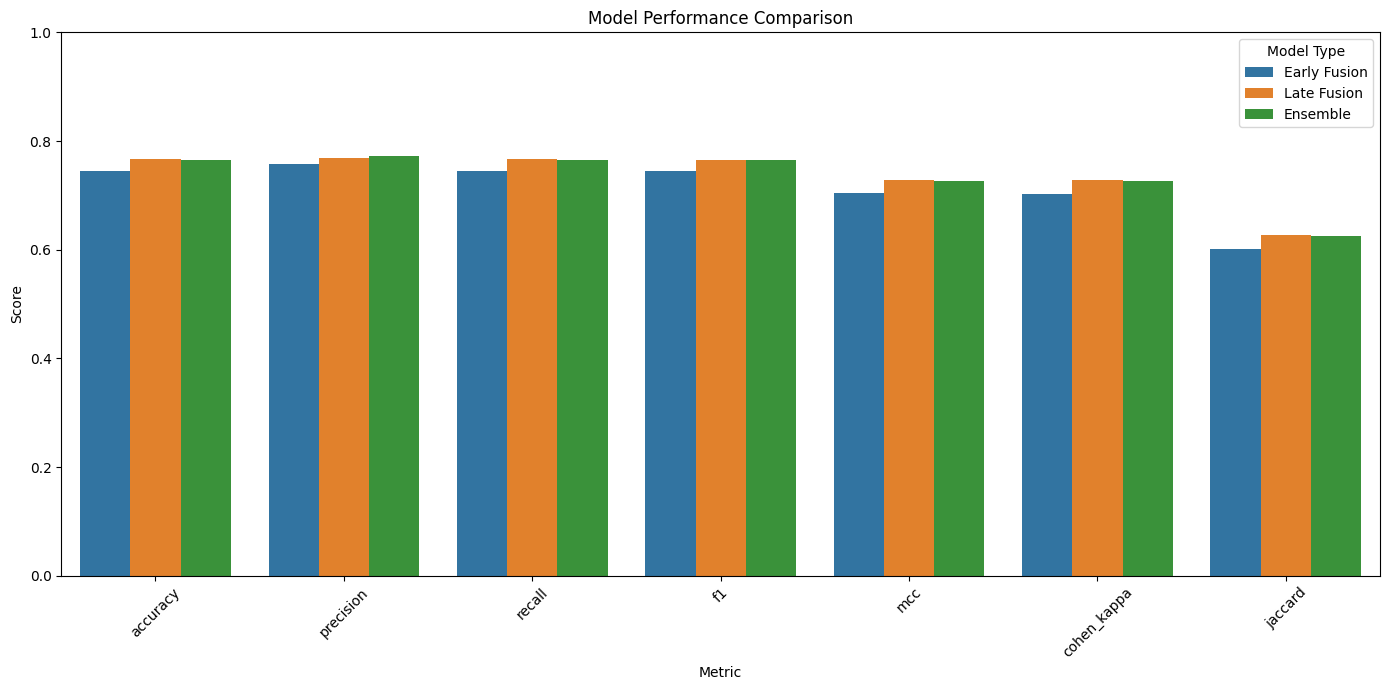

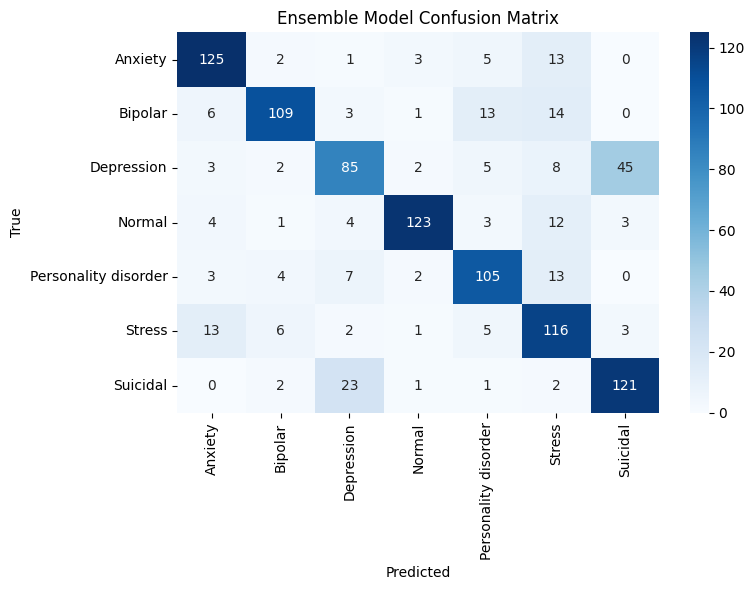


Ensemble Classification Report:


,Class,Precision,Recall,F1-Score,Support
0,Anxiety,0.811688,0.838926,0.825083,149
1,Bipolar,0.865079,0.746575,0.801471,146
2,Depression,0.680000,0.566667,0.618182,150
3,Normal,0.924812,0.820000,0.869258,150
4,Personality disorder,0.766423,0.783582,0.774908,134
5,Stress,0.651685,0.794521,0.716049,146
6,Suicidal,0.703488,0.806667,0.751553,150


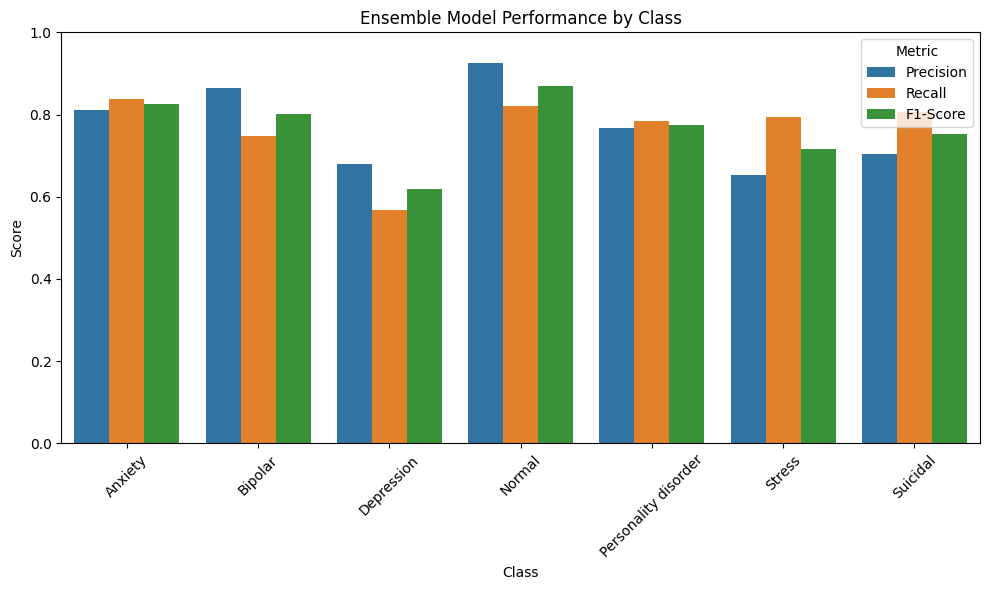


Ensemble Model Error Analysis:
Total errors for Ensemble: 241
Error rate: 23.51%

Most common error patterns:


,True Label,Predicted Label,Count
15,Depression,Suicidal,45
34,Suicidal,Depression,23
9,Bipolar,Stress,14
8,Bipolar,Personality disorder,13
4,Anxiety,Stress,13
27,Stress,Anxiety,13
26,Personality disorder,Stress,13
20,Normal,Stress,12
14,Depression,Stress,8
24,Personality disorder,Depression,7



Sample of misclassified texts (Ensemble):


,Text,True Label,Predicted Label
36,I feel like such a manchild sometimes for not ...,Suicidal,Stress
199,About a month ago my best friend was laying on...,Depression,Suicidal
138,BACKGROUND: paul and i met 1.5 years ago on ok...,Normal,Depression
238,I just went through a breakup and the girl wan...,Depression,Suicidal
24,am i forever going to be haunted by my ex-frie...,Personality disorder,Stress
168,Ruminating thought lead me to burning bridges....,Bipolar,Stress
98,The whole story is a lot to type out and a bit...,Depression,Suicidal
173,Tomorrow's another day I'm having a hard time ...,Bipolar,Personality disorder
136,"Help! Overwhelming lust, and no idea if this i...",Bipolar,Stress
150,I don’t know what I’m supposed to do God these...,Stress,Bipolar


In [ ]:
# Run the ensemble evaluation
ensemble_model, ensemble_metrics, ensemble_cm, ensemble_cr, ensemble_preds, ensemble_labels = load_and_evaluate_ensemble()

# Compare all three models
comparison_df = pd.DataFrame({
    'Metric': list(early_metrics.keys()),
    'Early Fusion': list(early_metrics.values()),
    'Late Fusion': list(late_metrics.values()),
    'Ensemble': list(ensemble_metrics.values())
})

print("\nModel Comparison:")
display(comparison_df)

# Plot comparison
plt.figure(figsize=(14, 7))
comparison_df_plot = comparison_df[comparison_df['Metric'] != 'hamming_loss']  # Exclude hamming_loss as it's lower is better
comparison_df_plot = comparison_df_plot.melt(id_vars='Metric', var_name='Model', value_name='Score')
sns.barplot(x='Metric', y='Score', hue='Model', data=comparison_df_plot)
plt.title('Model Performance Comparison')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(title='Model Type')
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

# Plot confusion matrix for ensemble model
plt.figure(figsize=(8, 6))
sns.heatmap(ensemble_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=list(inverse_mapping.values()),
            yticklabels=list(inverse_mapping.values()))
plt.title('Ensemble Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('ensemble_confusion_matrix.png')
plt.show()

# Create and display ensemble classification report
print("\nEnsemble Classification Report:")
plot_classification_report(ensemble_cr, 'Ensemble Model Performance by Class')

# Analyze ensemble errors
print("\nEnsemble Model Error Analysis:")
test_texts = [test_dataset[i]['text'] for i in range(len(test_dataset))]
ensemble_error_samples = analyze_errors(ensemble_labels, ensemble_preds, test_texts, "Ensemble")
if ensemble_error_samples is not None:
    print("\nSample of misclassified texts (Ensemble):")
    display(ensemble_error_samples)


In [ ]:
# Save the ensemble model
torch.save({
    'model_state_dict': ensemble_model.state_dict(),
    'early_fusion_state_dict': early_fusion_model.state_dict(),
    'late_fusion_state_dict': late_fusion_model.state_dict(),
    'num_classes': num_classes,
    'label_mapping': label_mapping,
    'inverse_mapping': inverse_mapping,
}, 'best_ensemble_hybrid_transformer_model.pt')

print(f"Ensemble model saved to 'best_ensemble_hybrid_transformer_model.pt'")


Ensemble model saved to 'best_ensemble_hybrid_transformer_model.pt'


In [ ]:
!pip install ftfy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00


In [ ]:
import ftfy

# Sample input text with proper multiline string and encoding fix
sample_texts = [
    """My anxiety is telling me not to be honest/vulnerable I have a second date 
(anxiety is also telling me it’s not a date and that I’m not of interest to anyone 
other than people that try to take advantage of me.) with someone next week. 
I am so excited because the first date was a /blast/. My anxiety is telling me to 
play it cool, and not to look too eager and to only express interest if they express 
interest first. I would have listened in the past. I think it would be in my best 
interest to tell them I’m looking forward to it because I am. So, I am going to 
tell them that I’m excited to see them next week. Better to be myself and turn-off 
someone that isn’t interested in my genuine excitement to spend time with them 
than it is to keep pretending."""
]

# Fix potential character encoding issues (â€™ → ’ etc.)
sample_texts = [ftfy.fix_text(text) for text in sample_texts]

# Run prediction
print("\nSample predictions:")
for text in sample_texts:
    prediction = predict_sentiment_ensemble(
        text, 
        ensemble_model, 
        distilbert_tokenizer, 
        xlmr_tokenizer
    )
    print(f"\nText: '{text}'")
    print(f"Ensemble prediction: {prediction['ensemble_sentiment']} (confidence: {prediction['ensemble_confidence']:.4f})")
    print(f"Early fusion: {prediction['early_fusion_sentiment']} (confidence: {prediction['early_fusion_confidence']:.4f})")
    print(f"Late fusion: {prediction['late_fusion_sentiment']} (confidence: {prediction['late_fusion_confidence']:.4f})")
    print(f"Model weights: {prediction['model_weights']}")



Sample predictions:

Text: 'My anxiety is telling me not to be honest/vulnerable I have a second date 
(anxiety is also telling me it's not a date and that I'm not of interest to anyone 
other than people that try to take advantage of me.) with someone next week. 
I am so excited because the first date was a /blast/. My anxiety is telling me to 
play it cool, and not to look too eager and to only express interest if they express 
interest first. I would have listened in the past. I think it would be in my best 
interest to tell them I'm looking forward to it because I am. So, I am going to 
tell them that I'm excited to see them next week. Better to be myself and turn-off 
someone that isn't interested in my genuine excitement to spend time with them 
than it is to keep pretending.'
Ensemble prediction: Anxiety (confidence: 0.9590)
Early fusion: Anxiety (confidence: 0.8028)
Late fusion: Anxiety (confidence: 0.9869)
Model weights: [0.42715684 0.5728432 ]


In [ ]:
import ftfy

# Sample input text with proper multiline string and encoding fix
sample_texts = [
    """But what do I know? I keep reassuring myself that this is normal, and never tell anyone about this - I'm surprising one of the top students at a selective high school, but I really want this to end. I'm good at hiding things like this, because I don't want others feeling pity for me for things they didn't cause or can change.   ---   **tl;dr**: Older brother psychologically and physically abuses me and my younger brother."""
]

# Fix potential character encoding issues (â€™ → ’ etc.)
sample_texts = [ftfy.fix_text(text) for text in sample_texts]

# Run prediction
print("\nSample predictions:")
for text in sample_texts:
    prediction = predict_sentiment_ensemble(
        text, 
        ensemble_model, 
        distilbert_tokenizer, 
        xlmr_tokenizer
    )
    print(f"\nText: '{text}'")
    print(f"Ensemble prediction: {prediction['ensemble_sentiment']} (confidence: {prediction['ensemble_confidence']:.4f})")
    print(f"Early fusion: {prediction['early_fusion_sentiment']} (confidence: {prediction['early_fusion_confidence']:.4f})")
    print(f"Late fusion: {prediction['late_fusion_sentiment']} (confidence: {prediction['late_fusion_confidence']:.4f})")
    print(f"Model weights: {prediction['model_weights']}")



Sample predictions:

Text: 'But what do I know? I keep reassuring myself that this is normal, and never tell anyone about this - I'm surprising one of the top students at a selective high school, but I really want this to end. I'm good at hiding things like this, because I don't want others feeling pity for me for things they didn't cause or can change.   ---   **tl;dr**: Older brother psychologically and physically abuses me and my younger brother.'
Ensemble prediction: Stress (confidence: 0.9718)
Early fusion: Stress (confidence: 0.9588)
Late fusion: Stress (confidence: 0.9786)
Model weights: [0.42715684 0.5728432 ]


In [ ]:
import ftfy

# New input text
sample_texts = [
    """What do you do when you're overwhelmed with stress? I don't have an actual reason 
to be stressed right now. But, right now I just feel overwhelmed. What are some healthy 
things I can do to manage the build up of stress?"""
]

# Fix potential character encoding issues
sample_texts = [ftfy.fix_text(text) for text in sample_texts]

# Run prediction
print("\nSample predictions:")
for text in sample_texts:
    prediction = predict_sentiment_ensemble(
        text, 
        ensemble_model, 
        distilbert_tokenizer, 
        xlmr_tokenizer
    )
    print(f"\nText: '{text}'")
    print(f"Ensemble prediction: {prediction['ensemble_sentiment']} (confidence: {prediction['ensemble_confidence']:.4f})")
    print(f"Early fusion: {prediction['early_fusion_sentiment']} (confidence: {prediction['early_fusion_confidence']:.4f})")
    print(f"Late fusion: {prediction['late_fusion_sentiment']} (confidence: {prediction['late_fusion_confidence']:.4f})")
    print(f"Model weights: {prediction['model_weights']}")



Sample predictions:

Text: 'What do you do when you're overwhelmed with stress? I don't have an actual reason 
to be stressed right now. But, right now I just feel overwhelmed. What are some healthy 
things I can do to manage the build up of stress?'
Ensemble prediction: Stress (confidence: 0.9948)
Early fusion: Stress (confidence: 0.9922)
Late fusion: Stress (confidence: 0.9960)
Model weights: [0.42715684 0.5728432 ]


In [ ]:
import ftfy

# New input text
sample_texts = [
    """Any older people with AvPD there? How does it evolve with age? I honestly feel despair when thinking about the future because deep down I know it's not going to get better. But I'd like to hear experiences from actually older people (older as 40+ but even 30+ may feel useful)

Plus, anyone recovered? Is it even truly possible to fully recover?"""
]

# Fix potential character encoding issues
sample_texts = [ftfy.fix_text(text) for text in sample_texts]

# Run prediction
print("\nSample predictions:")
for text in sample_texts:
    prediction = predict_sentiment_ensemble(
        text, 
        ensemble_model, 
        distilbert_tokenizer, 
        xlmr_tokenizer
    )
    print(f"\nText: '{text}'")
    print(f"Ensemble prediction: {prediction['ensemble_sentiment']} (confidence: {prediction['ensemble_confidence']:.4f})")
    print(f"Early fusion: {prediction['early_fusion_sentiment']} (confidence: {prediction['early_fusion_confidence']:.4f})")
    print(f"Late fusion: {prediction['late_fusion_sentiment']} (confidence: {prediction['late_fusion_confidence']:.4f})")
    print(f"Model weights: {prediction['model_weights']}")



Sample predictions:

Text: 'Any older people with AvPD there? How does it evolve with age? I honestly feel despair when thinking about the future because deep down I know it's not going to get better. But I'd like to hear experiences from actually older people (older as 40+ but even 30+ may feel useful)

Plus, anyone recovered? Is it even truly possible to fully recover?'
Ensemble prediction: Personality disorder (confidence: 0.9963)
Early fusion: Personality disorder (confidence: 0.9933)
Late fusion: Personality disorder (confidence: 0.9976)
Model weights: [0.42715684 0.5728432 ]


In [ ]:
import ftfy

# New input text
sample_texts = [
    """New kind of manic episode? I don't even know where to begin but u feel like I need to talk this through somewhere so here I am. I feel like I'm experiencing an completely different type of mania that is like no other... it's not super intense or anything but my risk taking behaviors are like whoa right now and I don't want to stop. 

It all started this weekend when I was partying (which I almost never do either)... drank way more than usual all weekend. Ended up experimenting with recreational drugs that I always swore I would never try. And I liked it! I also went crazy sexually and did some things I'm not very proud of, but still want to do it again (and the opportunity is 100% being presented to me on a gold platter). 

Im not having any of the normal mind racing, heart beating out of my chest, anxiety attack ridden mania than I usually have...wtf is this crap? 

Any words of advice?"""
]

# Fix potential character encoding issues
sample_texts = [ftfy.fix_text(text) for text in sample_texts]

# Run prediction
print("\nSample predictions:")
for text in sample_texts:
    prediction = predict_sentiment_ensemble(
        text, 
        ensemble_model, 
        distilbert_tokenizer, 
        xlmr_tokenizer
    )
    print(f"\nText: '{text}'")
    print(f"Ensemble prediction: {prediction['ensemble_sentiment']} (confidence: {prediction['ensemble_confidence']:.4f})")
    print(f"Early fusion: {prediction['early_fusion_sentiment']} (confidence: {prediction['early_fusion_confidence']:.4f})")
    print(f"Late fusion: {prediction['late_fusion_sentiment']} (confidence: {prediction['late_fusion_confidence']:.4f})")
    print(f"Model weights: {prediction['model_weights']}")



Sample predictions:

Text: 'New kind of manic episode? I don't even know where to begin but u feel like I need to talk this through somewhere so here I am. I feel like I'm experiencing an completely different type of mania that is like no other... it's not super intense or anything but my risk taking behaviors are like whoa right now and I don't want to stop. 

It all started this weekend when I was partying (which I almost never do either)... drank way more than usual all weekend. Ended up experimenting with recreational drugs that I always swore I would never try. And I liked it! I also went crazy sexually and did some things I'm not very proud of, but still want to do it again (and the opportunity is 100% being presented to me on a gold platter). 

Im not having any of the normal mind racing, heart beating out of my chest, anxiety attack ridden mania than I usually have...wtf is this crap? 

Any words of advice?'
Ensemble prediction: Bipolar (confidence: 0.9971)
Early fusion: Bipol

In [ ]:
import ftfy

# New input text
sample_texts = [
    """i didn't have time to get one from there."""
]

# Fix potential character encoding issues
sample_texts = [ftfy.fix_text(text) for text in sample_texts]

# Run prediction
print("\nSample predictions:")
for text in sample_texts:
    prediction = predict_sentiment_ensemble(
        text, 
        ensemble_model, 
        distilbert_tokenizer, 
        xlmr_tokenizer
    )
    print(f"\nText: '{text}'")
    print(f"Ensemble prediction: {prediction['ensemble_sentiment']} (confidence: {prediction['ensemble_confidence']:.4f})")
    print(f"Early fusion: {prediction['early_fusion_sentiment']} (confidence: {prediction['early_fusion_confidence']:.4f})")
    print(f"Late fusion: {prediction['late_fusion_sentiment']} (confidence: {prediction['late_fusion_confidence']:.4f})")
    print(f"Model weights: {prediction['model_weights']}")



Sample predictions:

Text: 'i didn't have time to get one from there.'
Ensemble prediction: Normal (confidence: 0.9976)
Early fusion: Normal (confidence: 0.9968)
Late fusion: Normal (confidence: 0.9980)
Model weights: [0.42715684 0.5728432 ]
